# Minimum Reward Achieved for Different Number of Agents

In [1]:
from environment import TrafficEnvironment
from keychain import Keychain as kc
import os
import copy
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import PPO
import supersuit as ss
from Sumo_controller import Sumo
import seaborn as sns
from utilities import confirm_env_variable
from utilities import get_params
import matplotlib.pyplot as plt

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


In [3]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

In [4]:
list_number_of_agents = [1, 5, 50, 100, 200, 300, 400, 500, 600]

Empty the file that saves the minimum rewards for every episode

In [5]:
file_path = 'min_reward.txt'  

with open(file_path, 'w'):
    pass

In [6]:
#Loop over the different number of agents
for num_agents in list_number_of_agents:

    #Change the number of agents for each iteration
    agent_generation_params = params[kc.AGENTS_GENERATION_PARAMETERS]

    for key, value in agent_generation_params.items():
        if key == "num_agents":
            agent_generation_params[key] = num_agents

    params[kc.AGENTS_GENERATION_PARAMETERS] = agent_generation_params

    #create the environment with the specidied number of agents
    env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

    env = ss.pettingzoo_env_to_vec_env_v1(env)
    env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

    tuned_params = {
            "gamma": 0.9,
            "learning_rate": 1e-3,
        }

    model = PPO(
        "MlpPolicy",
        env,
        verbose = 1,
        n_steps = 10,
        batch_size=10,
        device = "cuda",
        **tuned_params
    )

    model.learn(total_timesteps=1000 * num_agents)

    env.close()

[SUCCESS] Generated 4 routes
[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Simulator is ready to simulate!
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [1.0589035614245699, 2.0712653383887756, 3.2277911164465785], (0, 1): [0.7676270508203282, 2.6846707005336334, 0.7787715086034414], (1, 0): [0.7396357391048572, 0.6873687704023294, 0.9195730415996491], (1, 1): [2.0234492645150217, 2.0365745146150616, 3.217137510151649]}

[SUCCESS] Free flow times calculated!

Agent 0 has origin 0 and destination 0.


Using cpu device
---------------------------
| time/              |    |
|    fps             | 1  |
|    iterations      | 1  |
|    time_elapsed    | 9  |
|    total_timesteps | 10 |
---------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 0           |
|    iterations           | 2           |
|    time_elapsed         | 20          |
|    total_timesteps      | 20     

Plot the minimum reward that was reached for every different environment

c:\Users\Anastasia\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Anastasia\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


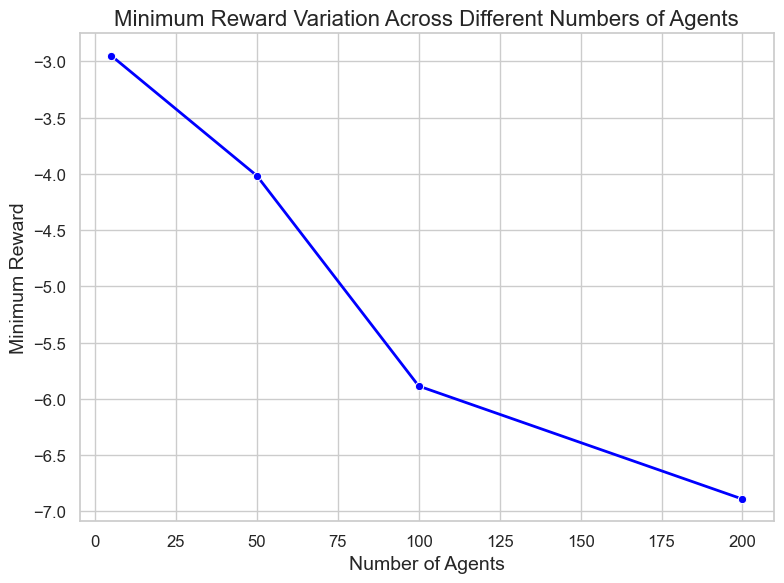

In [ ]:
import matplotlib.pyplot as plt

# Read the values from the file
file_path = 'min_reward.txt'  # Specify the path to your file
with open(file_path, 'r') as file:
    values = [float(line.strip()) for line in file]

# Set seaborn style
sns.set(style='whitegrid')

# Plot the values with custom x-axis values
plt.figure(figsize=(8, 6))  # Adjust the figure size as needed
sns.lineplot(x=list_number_of_agents, y=values, marker='o', color='blue', linewidth=2)
plt.xlabel('Number of Agents', fontsize=14)
plt.ylabel('Minimum Reward', fontsize=14)
plt.title('Minimum Reward Variation Across Different Numbers of Agents', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()